In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

tickers = ["BX", "KKR", "APO", "CG"]
benchmark = "SPY"   # S&P 500 proxy

data = yf.download(
    tickers + [benchmark],
    start="2017-01-01",
    end="2027-01-01",
    auto_adjust=True,
    progress=False,
    threads=False
)["Close"].dropna(how="all")


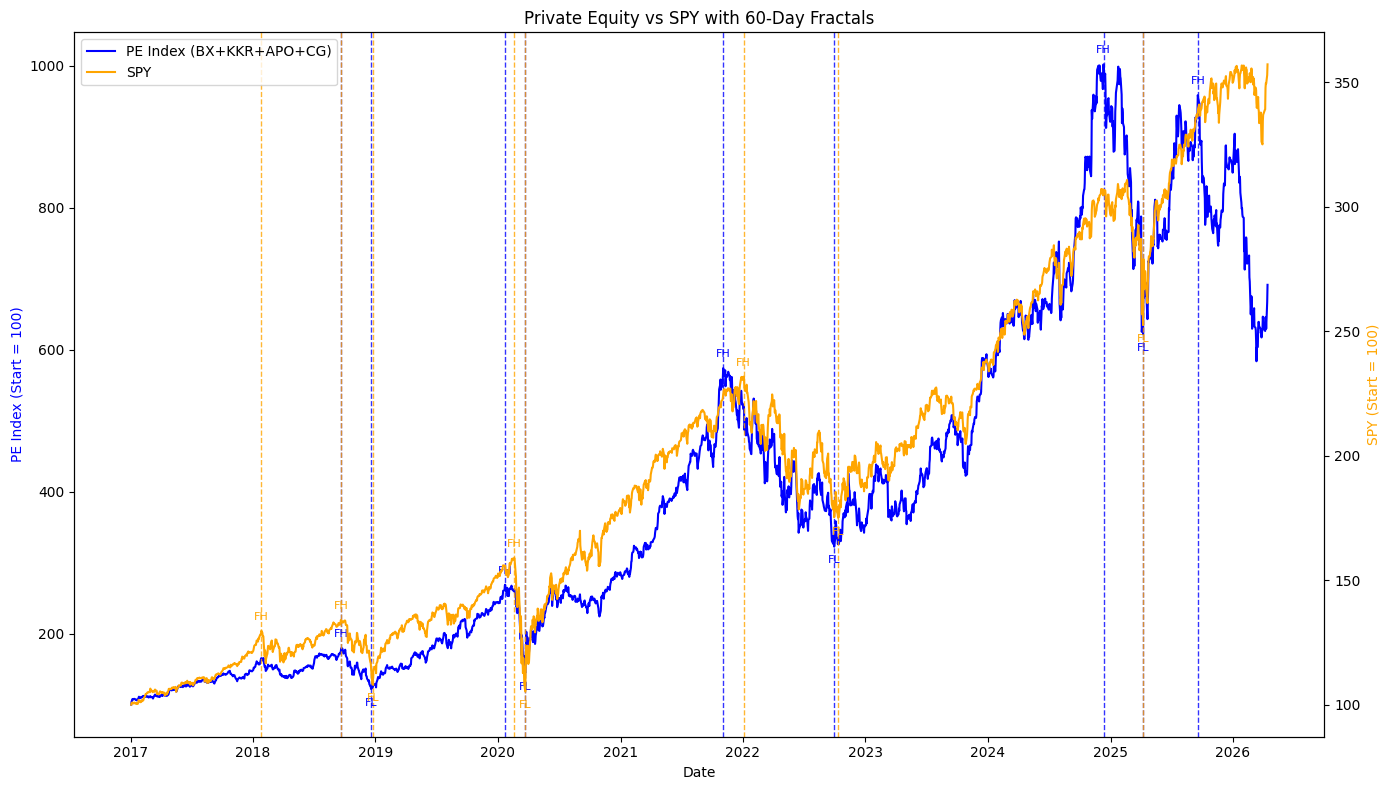

               PE_Index         SPY  PE_Fractal_High  PE_Fractal_Low  \
Date                                                                   
2018-01-26   165.568204  129.706762            False           False   
2018-09-20   175.418966  134.006191            False           False   
2018-09-21   179.443126  133.883787             True           False   
2018-12-20   122.192863  113.332817            False            True   
2018-12-24   124.067912  108.077448            False           False   
2020-01-23   269.019819  155.886018             True           False   
2020-02-19   262.723043  158.996987            False           False   
2020-03-23   144.740927  105.387542            False            True   
2021-11-03   573.957064  224.641583             True           False   
2022-01-03   515.838219  231.732122            False           False   
2022-09-30   322.585843  175.270380            False            True   
2022-10-12   330.727723  174.966096            False           F

In [2]:
result = pd.DataFrame(index=data.index)
result["PE_Index"] = data[tickers].mean(axis=1)
result["SPY"] = data[benchmark]
result = result.dropna()

normalized = result / result.iloc[0] * 100

# ---------------------------------
# 60-day centered fractal detection
# ---------------------------------
window = 240
half_window = window // 2

def fractal_flags(series, window=60, min_gap=10):
    roll_max = series.rolling(window=window, center=True).max()
    roll_min = series.rolling(window=window, center=True).min()

    high = (series == roll_max).fillna(False)
    low = (series == roll_min).fillna(False)

    # reduce clustered signals
    def reduce_clustered(mask, min_gap=10):
        pos = np.where(mask)[0]
        keep = np.zeros(len(mask), dtype=bool)
        last = -10**9
        for i in pos:
            if i - last >= min_gap:
                keep[i] = True
                last = i
        return pd.Series(keep, index=mask.index)

    high = reduce_clustered(high, min_gap=min_gap)
    low = reduce_clustered(low, min_gap=min_gap)
    return high, low

pe_high, pe_low = fractal_flags(normalized["PE_Index"], window=window, min_gap=10)
spy_high, spy_low = fractal_flags(normalized["SPY"], window=window, min_gap=10)

# ---------------------------------
# Colors
# ---------------------------------
pe_color = "blue"
spy_color = "orange"

# ---------------------------------
# Plot
# ---------------------------------
fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# main lines
ax1.plot(normalized.index, normalized["PE_Index"], color=pe_color, label="PE Index (BX+KKR+APO+CG)")
ax2.plot(normalized.index, normalized["SPY"], color=spy_color, label="SPY")

# fractal points: PE
pe_high_pts = normalized.loc[pe_high, "PE_Index"]
pe_low_pts  = normalized.loc[pe_low, "PE_Index"]

# ax1.scatter(pe_high_pts.index, pe_high_pts.values, marker="^", s=70, color=pe_color, label="PE Fractal High")
# ax1.scatter(pe_low_pts.index, pe_low_pts.values, marker="v", s=70, color=pe_color, label="PE Fractal Low")

# fractal points: SPY
spy_high_pts = normalized.loc[spy_high, "SPY"]
spy_low_pts  = normalized.loc[spy_low, "SPY"]

# ax2.scatter(spy_high_pts.index, spy_high_pts.values, marker="^", s=70, color=spy_color, label="SPY Fractal High")
# ax2.scatter(spy_low_pts.index, spy_low_pts.values, marker="v", s=70, color=spy_color, label="SPY Fractal Low")

# labels
for x, y in pe_high_pts.items():
    ax1.annotate("FH", xy=(x, y), xytext=(0, 8), textcoords="offset points",
                 ha="center", fontsize=8, color=pe_color)

for x, y in pe_low_pts.items():
    ax1.annotate("FL", xy=(x, y), xytext=(0, -12), textcoords="offset points",
                 ha="center", fontsize=8, color=pe_color)

for x, y in spy_high_pts.items():
    ax2.annotate("FH", xy=(x, y), xytext=(0, 8), textcoords="offset points",
                 ha="center", fontsize=8, color=spy_color)

for x, y in spy_low_pts.items():
    ax2.annotate("FL", xy=(x, y), xytext=(0, -12), textcoords="offset points",
                 ha="center", fontsize=8, color=spy_color)

# ---------------------------------
# Vertical lines for fractal dates
# blue = private equity index
# orange = SPY
# ---------------------------------
for dt in pe_high_pts.index.union(pe_low_pts.index):
    ax1.axvline(dt, color=pe_color, linestyle="--", alpha=0.8, linewidth=1)

for dt in spy_high_pts.index.union(spy_low_pts.index):
    ax1.axvline(dt, color=spy_color, linestyle="--", alpha=0.8, linewidth=1)

# ---------------------------------
# Optional: show the full 60-day fractal period around each fractal point
# Uncomment this block if you want shaded windows instead of only vertical lines
# ---------------------------------
# idx = normalized.index
# for dt in pe_high_pts.index.union(pe_low_pts.index):
#     loc = idx.get_loc(dt)
#     left = idx[max(0, loc - half_window)]
#     right = idx[min(len(idx) - 1, loc + half_window)]
#     ax1.axvspan(left, right, color=pe_color, alpha=0.03)
#
# for dt in spy_high_pts.index.union(spy_low_pts.index):
#     loc = idx.get_loc(dt)
#     left = idx[max(0, loc - half_window)]
#     right = idx[min(len(idx) - 1, loc + half_window)]
#     ax1.axvspan(left, right, color=spy_color, alpha=0.03)

# formatting
ax1.set_title("Private Equity vs SPY with 60-Day Fractals")
ax1.set_xlabel("Date")
ax1.set_ylabel("PE Index (Start = 100)", color=pe_color)
ax2.set_ylabel("SPY (Start = 100)", color=spy_color)
# ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

# export fractal table
fractals = pd.DataFrame(index=normalized.index)
fractals["PE_Index"] = normalized["PE_Index"]
fractals["SPY"] = normalized["SPY"]
fractals["PE_Fractal_High"] = pe_high
fractals["PE_Fractal_Low"] = pe_low
fractals["SPY_Fractal_High"] = spy_high
fractals["SPY_Fractal_Low"] = spy_low

print(fractals[
    fractals["PE_Fractal_High"] |
    fractals["PE_Fractal_Low"] |
    fractals["SPY_Fractal_High"] |
    fractals["SPY_Fractal_Low"]
].tail(30))